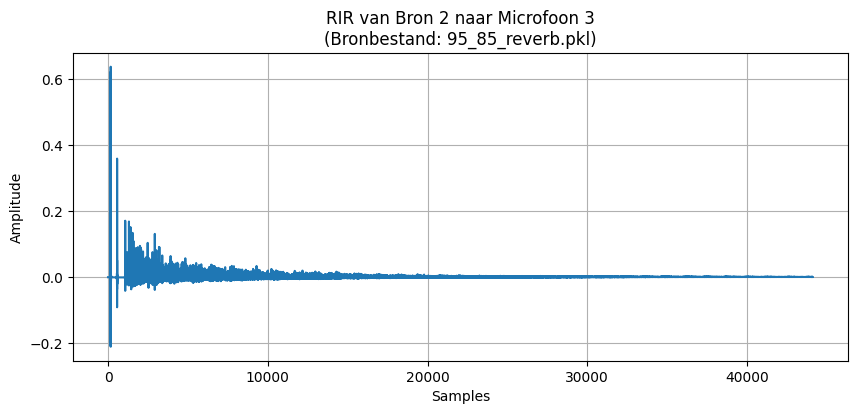

In [1]:
import sys
import os
import matplotlib.pyplot as plt

# This adds the parent directory to the search path
sys.path.append(os.path.abspath('..'))

from package import load_rirs, select_latest_rir

path_to_rirs_folder = '../rirs'

# Check if the folder exists and contains files
if not os.path.isdir(path_to_rirs_folder):
    raise FileNotFoundError(f"Folder '{path_to_rirs_folder}' not found. Make sure it exists in the current working directory: {os.getcwd()}")

pkl_files = [f for f in os.listdir(path_to_rirs_folder) if f.endswith('.pkl')]
if not pkl_files:
    raise FileNotFoundError(f"No .pkl RIR files found in '{path_to_rirs_folder}'. Please add RIR files to: {os.path.abspath(path_to_rirs_folder)}")

path_to_file = select_latest_rir(path_to_rirs_folder)

acousticScenario = load_rirs(path=path_to_file)

rir = acousticScenario.RIRs_audio[:, 2, 0]

plt.figure(figsize=(10, 4))
plt.plot(rir)
plt.title(f'RIR van Bron 2 naar Microfoon 3\n(Bronbestand: {os.path.basename(path_to_file)})')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)

output_file = 'mijn_rir_grafiek.png'
plt.savefig(output_file)
plt.show()